# BrushCue Example: Star Cut Out

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/star_cut_out.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/star-cut-out

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


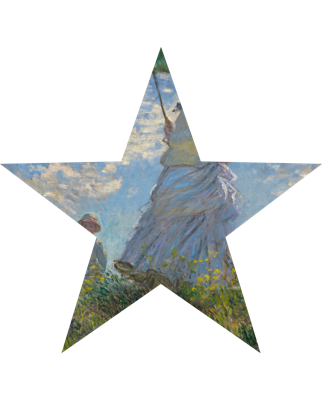

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
bounds = bc.Composition.bounds(input_image)
img_w = bc.Bounds2f.width(bounds)
cx = img_w * 0.5
img_h = bc.Bounds2f.height(bounds)
pi = bc.Float.pi()
sin54 = bc.Float.sin((pi * 0.3))
outer_r_from_h = img_h / (1.0 + sin54)
cos18 = bc.Float.cos((pi * 0.1))
outer_r_from_w = img_w / (2.0 * cos18)
outer_r = bc.Float.min(outer_r_from_h, outer_r_from_w)
a0 = pi * (-0.5)
cy = (img_h * 0.5) + ((outer_r * (1.0 - sin54)) * 0.5)
p0 = bc.Point2f.from_components(
    (cx + (outer_r * bc.Float.cos(a0))), (cy + (outer_r * bc.Float.sin(a0)))
)
inner_r = outer_r * 0.4
a1 = a0 + (pi * 0.2)
p1 = bc.Point2f.from_components(
    (cx + (inner_r * bc.Float.cos(a1))), (cy + (inner_r * bc.Float.sin(a1)))
)
a2 = a1 + (pi * 0.2)
p2 = bc.Point2f.from_components(
    (cx + (outer_r * bc.Float.cos(a2))), (cy + (outer_r * bc.Float.sin(a2)))
)
a3 = a2 + (pi * 0.2)
p3 = bc.Point2f.from_components(
    (cx + (inner_r * bc.Float.cos(a3))), (cy + (inner_r * bc.Float.sin(a3)))
)
a4 = a3 + (pi * 0.2)
p4 = bc.Point2f.from_components(
    (cx + (outer_r * bc.Float.cos(a4))), (cy + (outer_r * bc.Float.sin(a4)))
)
a5 = a4 + (pi * 0.2)
p5 = bc.Point2f.from_components(
    (cx + (inner_r * bc.Float.cos(a5))), (cy + (inner_r * bc.Float.sin(a5)))
)
a6 = a5 + (pi * 0.2)
p6 = bc.Point2f.from_components(
    (cx + (outer_r * bc.Float.cos(a6))), (cy + (outer_r * bc.Float.sin(a6)))
)
a7 = a6 + (pi * 0.2)
p7 = bc.Point2f.from_components(
    (cx + (inner_r * bc.Float.cos(a7))), (cy + (inner_r * bc.Float.sin(a7)))
)
a8 = a7 + (pi * 0.2)
p8 = bc.Point2f.from_components(
    (cx + (outer_r * bc.Float.cos(a8))), (cy + (outer_r * bc.Float.sin(a8)))
)
a9 = a8 + (pi * 0.2)
p9 = bc.Point2f.from_components(
    (cx + (inner_r * bc.Float.cos(a9))), (cy + (inner_r * bc.Float.sin(a9)))
)
path = (
    bc.Path.new()
    .move_to_point(p0)
    .line_to_point(p1)
    .line_to_point(p2)
    .line_to_point(p3)
    .line_to_point(p4)
    .line_to_point(p5)
    .line_to_point(p6)
    .line_to_point(p7)
    .line_to_point(p8)
    .line_to_point(p9)
    .line_to_point(p0)
)
star_color = bc.ProfiledColor.from_rgba_srgb(
    bc.RGBAColor.from_components(1.0, 1.0, 1.0, 1.0)
)
fill = bc.Fill.solid(star_color)
render_style = bc.RenderStyle.fill_only(fill)
painter = bc.Painter.new().add_path_with_render_style(
    path, render_style, bc.Object.to_list(bc.Transform2.identity())
)
star = bc.Composition.painter(painter)
graph = star.blend_stencil(input_image, bc.Transform2.identity())

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
